# Plotting a graph over time of the affilitions

In [23]:
import pandas as pd
import numpy as np
melted_master_condenced = pd.read_excel('/Users/MattJohnson/Desktop/Affiliations/6. Results/6.A. Data created in 6./6.2/RES_Melted_Weights_applied.xlsx') 
print(melted_master_condenced.shape)
melted_master_condenced = melted_master_condenced[['Article_ID','Weight','Affiliation','year']]
melted_master_condenced = melted_master_condenced.reset_index(drop=True)
melted_master_condenced.head()

(4309, 7)


,Article_ID,Weight,Affiliation,year
0,2967475,1.0,Cambridge Massachusetts United States (City),1940
1,2967402,0.5,Birmingham United Kingdom (City),1940
2,2967417,1.0,Ames Iowa United States (City),1940
3,2967419,1.0,Chicago Illinois United States (City),1940
4,2967418,1.0,London United Kingdom (City),1940


In [24]:
melted_master_condenced['decade'] = ''
melted_master_condenced['decade'] = np.where((melted_master_condenced['year'] >= 1940) & (melted_master_condenced['year'] < 1950), '[1940,1949]', melted_master_condenced['decade'])
melted_master_condenced['decade'] = np.where((melted_master_condenced['year'] >= 1950) & (melted_master_condenced['year'] < 1960), '[1950,1959]', melted_master_condenced['decade'])
melted_master_condenced['decade'] = np.where((melted_master_condenced['year'] >= 1960) & (melted_master_condenced['year'] < 1970), '[1960,1969]', melted_master_condenced['decade'])
melted_master_condenced['decade'] = np.where((melted_master_condenced['year'] >= 1970) & (melted_master_condenced['year'] < 1980), '[1970,1979]', melted_master_condenced['decade'])
melted_master_condenced['decade'] = np.where((melted_master_condenced['year'] >= 1980) & (melted_master_condenced['year'] < 1990), '[1980,1989]', melted_master_condenced['decade'])
melted_master_condenced['decade'] = np.where((melted_master_condenced['year'] >= 1990) & (melted_master_condenced['year'] < 2000), '[1990,1999]', melted_master_condenced['decade'])
melted_master_condenced['decade'] = np.where((melted_master_condenced['year'] >= 2000) & (melted_master_condenced['year'] < 2011), '[2000,2010]', melted_master_condenced['decade'])
print(melted_master_condenced.head())
print(melted_master_condenced.tail())

   Article_ID  Weight                                   Affiliation  year  \
0     2967475     1.0  Cambridge Massachusetts United States (City)  1940   
1     2967402     0.5              Birmingham United Kingdom (City)  1940   
2     2967417     1.0                Ames Iowa United States (City)  1940   
3     2967419     1.0         Chicago Illinois United States (City)  1940   
4     2967418     1.0                  London United Kingdom (City)  1940   

        decade  
0  [1940,1949]  
1  [1940,1949]  
2  [1940,1949]  
3  [1940,1949]  
4  [1940,1949]  
      Article_ID  Weight                            Affiliation  year  \
4304    40836656    0.50                   Princeton University  2010   
4305    40836658    0.25  University Of California, Los Angeles  2010   
4306    40587636    0.50               Johns Hopkins University  2010   
4307    40587620    0.50              University College London  2010   
4308    40587626    0.20     California Institute Of Technology  2010 

# Ranking the Universities based on their number of papers per published per decade

In [25]:
#Gets the top 10 overall
melted_master_condenced = melted_master_condenced.sort_values(by=['year'])
melted_master_condenced['aff_cum_sum'] = melted_master_condenced.groupby(['Affiliation'])['Weight'].cumsum()

mask_journal = melted_master_condenced['Affiliation'].isin(['National Bureau Of Economic Research'])
melted_master_condenced = melted_master_condenced[~mask_journal]

highest_vals = melted_master_condenced.drop_duplicates(subset = ['Affiliation'], keep = 'last')
highest_vals_10 = highest_vals.nlargest(25,'aff_cum_sum')
print(highest_vals_10.shape)
#print(highest_vals_10.head())
print(highest_vals_10.iat[6,2])

melted_master_condenced_decade = melted_master_condenced[['Article_ID','Weight','Affiliation','decade']]

a = melted_master_condenced_decade.loc[melted_master_condenced_decade['Affiliation'] == highest_vals_10.iat[6,2]]
a['aff_cum_counts_yearly'] = a.groupby(['Affiliation','decade'])['Weight'].cumsum()
a = a.drop_duplicates(subset = ['decade'], keep = 'last')
print(a.head())
print(a.shape)

(25, 6)
Harvard University
      Article_ID  Weight         Affiliation       decade  \
684      2296434    1.00  Harvard University  [1960,1969]   
1448     2297175    1.00  Harvard University  [1970,1979]   
2275     2297746    0.25  Harvard University  [1980,1989]   
3046     2567020    1.00  Harvard University  [1990,1999]   
4196    40835858    0.25  Harvard University  [2000,2010]   

      aff_cum_counts_yearly  
684                6.000000  
1448              15.333333  
2275              12.083333  
3046              15.916667  
4196               6.611111  
(5, 5)


/var/folders/23/ft9qf9c11rj_vqhbjml910f40000gn/T/ipykernel_15189/1670870116.py:17: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  a['aff_cum_counts_yearly'] = a.groupby(['Affiliation','decade'])['Weight'].cumsum()


In [26]:
a = melted_master_condenced_decade.loc[melted_master_condenced_decade['Affiliation'] == highest_vals_10.iat[0,2]]
a['aff_cum_sum_decade'] = a.groupby(['Affiliation','decade'])['Weight'].cumsum()
a = a.drop_duplicates(subset = ['decade'], keep = 'last')
print(a.shape)

b = melted_master_condenced_decade.loc[melted_master_condenced_decade['Affiliation'] == highest_vals_10.iat[1,2]]
b['aff_cum_sum_decade'] = b.groupby(['Affiliation','decade'])['Weight'].cumsum()
b = b.drop_duplicates(subset = ['decade'], keep = 'last')
print(b.shape)

c = melted_master_condenced_decade.loc[melted_master_condenced_decade['Affiliation'] == highest_vals_10.iat[2,2]]
c['aff_cum_sum_decade'] = c.groupby(['Affiliation','decade'])['Weight'].cumsum()
c = c.drop_duplicates(subset = ['decade'], keep = 'last')
print(c.shape)

d = melted_master_condenced_decade.loc[melted_master_condenced_decade['Affiliation'] == highest_vals_10.iat[3,2]]
d['aff_cum_sum_decade'] = d.groupby(['Affiliation','decade'])['Weight'].cumsum()
d = d.drop_duplicates(subset = ['decade'], keep = 'last')
print(d.shape)

e = melted_master_condenced_decade.loc[melted_master_condenced_decade['Affiliation'] == highest_vals_10.iat[4,2]]
e['aff_cum_sum_decade'] = e.groupby(['Affiliation','decade'])['Weight'].cumsum()
e = e.drop_duplicates(subset = ['decade'], keep = 'last')
print(e.shape)

f = melted_master_condenced_decade.loc[melted_master_condenced_decade['Affiliation'] == highest_vals_10.iat[5,2]]
f['aff_cum_sum_decade'] = f.groupby(['Affiliation','decade'])['Weight'].cumsum()
f = f.drop_duplicates(subset = ['decade'], keep = 'last')
print(f.shape)

g = melted_master_condenced_decade.loc[melted_master_condenced_decade['Affiliation'] == highest_vals_10.iat[6,2]]
g['aff_cum_sum_decade'] = g.groupby(['Affiliation','decade'])['Weight'].cumsum()
g = g.drop_duplicates(subset = ['decade'], keep = 'last')
print(g.shape)

h = melted_master_condenced_decade.loc[melted_master_condenced_decade['Affiliation'] == highest_vals_10.iat[7,2]]
h['aff_cum_sum_decade'] = h.groupby(['Affiliation','decade'])['Weight'].cumsum()
h = h.drop_duplicates(subset = ['decade'], keep = 'last')
print(h.shape)

i = melted_master_condenced_decade.loc[melted_master_condenced_decade['Affiliation'] == highest_vals_10.iat[8,2]]
i['aff_cum_sum_decade'] = i.groupby(['Affiliation','decade'])['Weight'].cumsum()
i = i.drop_duplicates(subset = ['decade'], keep = 'last')
print(i.shape)

j = melted_master_condenced_decade.loc[melted_master_condenced_decade['Affiliation'] == highest_vals_10.iat[9,2]]
j['aff_cum_sum_decade'] = j.groupby(['Affiliation','decade'])['Weight'].cumsum()
j = j.drop_duplicates(subset = ['decade'], keep = 'last')
print(j.shape)

k = melted_master_condenced_decade.loc[melted_master_condenced_decade['Affiliation'] == highest_vals_10.iat[10,2]]
k['aff_cum_sum_decade'] = k.groupby(['Affiliation','decade'])['Weight'].cumsum()
k = k.drop_duplicates(subset = ['decade'], keep = 'last')
print(k.shape)

l = melted_master_condenced_decade.loc[melted_master_condenced_decade['Affiliation'] == highest_vals_10.iat[11,2]]
l['aff_cum_sum_decade'] = l.groupby(['Affiliation','decade'])['Weight'].cumsum()
l = l.drop_duplicates(subset = ['decade'], keep = 'last')
print(l.shape)

m = melted_master_condenced_decade.loc[melted_master_condenced_decade['Affiliation'] == highest_vals_10.iat[12,2]]
m['aff_cum_sum_decade'] = m.groupby(['Affiliation','decade'])['Weight'].cumsum()
m = m.drop_duplicates(subset = ['decade'], keep = 'last')
print(m.shape)

n = melted_master_condenced_decade.loc[melted_master_condenced_decade['Affiliation'] == highest_vals_10.iat[13,2]]
n['aff_cum_sum_decade'] = n.groupby(['Affiliation','decade'])['Weight'].cumsum()
n = n.drop_duplicates(subset = ['decade'], keep = 'last')
print(n.shape)

o = melted_master_condenced_decade.loc[melted_master_condenced_decade['Affiliation'] == highest_vals_10.iat[14,2]]
o['aff_cum_sum_decade'] = o.groupby(['Affiliation','decade'])['Weight'].cumsum()
o = o.drop_duplicates(subset = ['decade'], keep = 'last')
print(o.shape)

p = melted_master_condenced_decade.loc[melted_master_condenced_decade['Affiliation'] == highest_vals_10.iat[15,2]]
p['aff_cum_sum_decade'] = p.groupby(['Affiliation','decade'])['Weight'].cumsum()
p = p.drop_duplicates(subset = ['decade'], keep = 'last')
print(p.shape)

q = melted_master_condenced_decade.loc[melted_master_condenced_decade['Affiliation'] == highest_vals_10.iat[16,2]]
q['aff_cum_sum_decade'] = q.groupby(['Affiliation','decade'])['Weight'].cumsum()
q = q.drop_duplicates(subset = ['decade'], keep = 'last')
print(q.shape)

r = melted_master_condenced_decade.loc[melted_master_condenced_decade['Affiliation'] == highest_vals_10.iat[17,2]]
r['aff_cum_sum_decade'] = r.groupby(['Affiliation','decade'])['Weight'].cumsum()
r = r.drop_duplicates(subset = ['decade'], keep = 'last')
print(r.shape)

s = melted_master_condenced_decade.loc[melted_master_condenced_decade['Affiliation'] == highest_vals_10.iat[18,2]]
s['aff_cum_sum_decade'] = s.groupby(['Affiliation','decade'])['Weight'].cumsum()
s = s.drop_duplicates(subset = ['decade'], keep = 'last')
print(s.shape)

t = melted_master_condenced_decade.loc[melted_master_condenced_decade['Affiliation'] == highest_vals_10.iat[19,2]]
t['aff_cum_sum_decade'] = t.groupby(['Affiliation','decade'])['Weight'].cumsum()
t = t.drop_duplicates(subset = ['decade'], keep = 'last')
print(t.shape)

u = melted_master_condenced_decade.loc[melted_master_condenced_decade['Affiliation'] == highest_vals_10.iat[20,2]]
u['aff_cum_sum_decade'] = u.groupby(['Affiliation','decade'])['Weight'].cumsum()
u = u.drop_duplicates(subset = ['decade'], keep = 'last')
print(u.shape)

v = melted_master_condenced_decade.loc[melted_master_condenced_decade['Affiliation'] == highest_vals_10.iat[21,2]]
v['aff_cum_sum_decade'] = v.groupby(['Affiliation','decade'])['Weight'].cumsum()
v = v.drop_duplicates(subset = ['decade'], keep = 'last')
print(v.shape)

w = melted_master_condenced_decade.loc[melted_master_condenced_decade['Affiliation'] == highest_vals_10.iat[22,2]]
w['aff_cum_sum_decade'] = w.groupby(['Affiliation','decade'])['Weight'].cumsum()
w = w.drop_duplicates(subset = ['decade'], keep = 'last')
print(w.shape)

x = melted_master_condenced_decade.loc[melted_master_condenced_decade['Affiliation'] == highest_vals_10.iat[23,2]]
x['aff_cum_sum_decade'] = x.groupby(['Affiliation','decade'])['Weight'].cumsum()
x = x.drop_duplicates(subset = ['decade'], keep = 'last')
print(x.shape)

y = melted_master_condenced_decade.loc[melted_master_condenced_decade['Affiliation'] == highest_vals_10.iat[24,2]]
y['aff_cum_sum_decade'] = y.groupby(['Affiliation','decade'])['Weight'].cumsum()
y = y.drop_duplicates(subset = ['decade'], keep = 'last')
print(y.shape)

/var/folders/23/ft9qf9c11rj_vqhbjml910f40000gn/T/ipykernel_15189/1100585584.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  a['aff_cum_sum_decade'] = a.groupby(['Affiliation','decade'])['Weight'].cumsum()
/var/folders/23/ft9qf9c11rj_vqhbjml910f40000gn/T/ipykernel_15189/1100585584.py:7: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  b['aff_cum_sum_decade'] = b.groupby(['Affiliation','decade'])['Weight'].cumsum()
/var/folders/23/ft9qf9c11rj_vqhbjml910f40000gn/T/ipykernel_15189/1100585584.py:12: SettingWith

(7, 5)
(5, 5)
(3, 5)
(5, 5)
(6, 5)
(6, 5)
(5, 5)


/var/folders/23/ft9qf9c11rj_vqhbjml910f40000gn/T/ipykernel_15189/1100585584.py:37: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  h['aff_cum_sum_decade'] = h.groupby(['Affiliation','decade'])['Weight'].cumsum()
/var/folders/23/ft9qf9c11rj_vqhbjml910f40000gn/T/ipykernel_15189/1100585584.py:42: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  i['aff_cum_sum_decade'] = i.groupby(['Affiliation','decade'])['Weight'].cumsum()
/var/folders/23/ft9qf9c11rj_vqhbjml910f40000gn/T/ipykernel_15189/1100585584.py:47: SettingWi

(5, 5)
(4, 5)
(5, 5)
(6, 5)
(5, 5)
(5, 5)
(5, 5)
(5, 5)
(5, 5)
(4, 5)


/var/folders/23/ft9qf9c11rj_vqhbjml910f40000gn/T/ipykernel_15189/1100585584.py:87: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  r['aff_cum_sum_decade'] = r.groupby(['Affiliation','decade'])['Weight'].cumsum()
/var/folders/23/ft9qf9c11rj_vqhbjml910f40000gn/T/ipykernel_15189/1100585584.py:92: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  s['aff_cum_sum_decade'] = s.groupby(['Affiliation','decade'])['Weight'].cumsum()
/var/folders/23/ft9qf9c11rj_vqhbjml910f40000gn/T/ipykernel_15189/1100585584.py:97: SettingWi

(5, 5)
(5, 5)
(5, 5)
(5, 5)
(5, 5)
(4, 5)
(5, 5)
(5, 5)


/var/folders/23/ft9qf9c11rj_vqhbjml910f40000gn/T/ipykernel_15189/1100585584.py:107: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  v['aff_cum_sum_decade'] = v.groupby(['Affiliation','decade'])['Weight'].cumsum()
/var/folders/23/ft9qf9c11rj_vqhbjml910f40000gn/T/ipykernel_15189/1100585584.py:112: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  w['aff_cum_sum_decade'] = w.groupby(['Affiliation','decade'])['Weight'].cumsum()
/var/folders/23/ft9qf9c11rj_vqhbjml910f40000gn/T/ipykernel_15189/1100585584.py:117: Settin

In [27]:
#ranked = pd.concat([a,b,c,d,e,f,g,h,i,j], axis=0)
#ranked = pd.concat([a,b,c,d,e,f,g,h,i,j,k,l,m,n,o], axis=0)
#ranked = pd.concat([a,b,c,d,e,f,g,h,i,j,k,l,m,n,o,p,q,r,s,t], axis=0)
ranked = pd.concat([a,b,c,d,e,f,g,h,i,j,k,l,m,n,o,p,q,r,s,t,u,v,w,x,y], axis=0)
ranked = ranked.sort_values(by=['decade','Affiliation'])
print(ranked.shape)

ranked['Rank'] = ranked.groupby(['decade'])['aff_cum_sum_decade'].rank(method = 'max', ascending= False)
print(ranked.shape)
print(ranked.tail(20))
#ranked.to_excel('/Users/MattJohnson/Desktop/Affiliations/2_Extracting affilitations/2_Fuzzy matching/Combined journals/Combined journal yearly rank.xlsx') 

(125, 5)
(125, 6)
      Article_ID    Weight                                     Affiliation  \
4196    40835858  0.250000                              Harvard University   
4198    40835860  0.333333                  Hebrew University Of Jerusalem   
4186    40836649  0.333333  London School Of Economics & Political Science   
4192    40835850  0.166667           Massachusetts Institute Of Technology   
4214    40587645  0.250000                             New York University   
4047    40247628  0.166667                         Northwestern University   
4206    40587621  0.333333                            Princeton University   
4175    40587626  0.100000                             Stanford University   
4077    40247628  0.166667                             Tel Aviv University   
4191    40836647  0.500000                  University Of British Columbia   
4213    40587644  0.500000              University Of California, Berkeley   
4200    40835854  0.083333           Universit

In [28]:
#ranked.to_excel('/Users/MattJohnson/Desktop/Affiliations/6. Results/6.A. Data created in 6./6.3/JPE_Ranked_data.xlsx') 

In [29]:
ranked = ranked.rename(columns={"decade": "Year Bucket"})

In [30]:
pivot = ranked.pivot(index='Year Bucket', columns='Affiliation', values='Rank')
pivot

Affiliation,Australian National University,Brown University,Cambridge Massachusetts United States (City),Columbia University,Harvard University,Hebrew University Of Jerusalem,London School Of Economics & Political Science,London United Kingdom (City),Massachusetts Institute Of Technology,New York University,...,"University Of California, Berkeley","University Of California, Los Angeles","University Of California, San Diego",University Of Cambridge,University Of Chicago,University Of Oxford,University Of Pennsylvania,University Of Rochester,University Of Toronto,Yale University
Year Bucket,,,,,,,,,,,,,,,,,,,,,
"[1940,1949]",NaN,NaN,3.0,NaN,NaN,NaN,NaN,1.0,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,2.0,NaN,NaN,NaN,NaN
"[1950,1959]",NaN,NaN,1.0,NaN,NaN,NaN,NaN,3.0,5.0,NaN,...,NaN,NaN,NaN,5.0,NaN,2.0,NaN,NaN,NaN,NaN
"[1960,1969]",19.0,12.0,1.0,23.0,9.0,6.0,15.0,9.0,2.0,NaN,...,3.0,22.0,22.0,5.0,12.0,4.0,13.0,16.0,22.0,10.0
"[1970,1979]",5.0,14.0,NaN,20.0,3.0,8.0,2.0,24.0,8.0,24.0,...,12.0,20.0,16.0,1.0,22.0,9.0,15.0,13.0,22.0,8.0
"[1980,1989]",14.0,22.0,NaN,6.0,8.0,17.0,1.0,NaN,4.0,20.0,...,10.0,16.0,12.0,18.0,13.0,7.0,2.0,23.0,19.0,11.0
"[1990,1999]",22.0,20.0,NaN,10.0,2.0,18.0,6.0,NaN,3.0,17.0,...,12.0,16.0,13.0,21.0,NaN,10.0,5.0,14.0,15.0,10.0
"[2000,2010]",23.0,12.0,NaN,10.0,15.0,18.0,6.0,NaN,9.0,2.0,...,11.0,16.0,22.0,21.0,8.0,4.0,5.0,19.0,7.0,14.0


In [31]:
pivot_ordered = pivot[['University Of Chicago','Massachusetts Institute Of Technology','Harvard University','University Of Pennsylvania','Northwestern University','Princeton University','Stanford University','Columbia University', 'University Of California, Los Angeles','Yale University']]
pivot_ordered

Affiliation,University Of Chicago,Massachusetts Institute Of Technology,Harvard University,University Of Pennsylvania,Northwestern University,Princeton University,Stanford University,Columbia University,"University Of California, Los Angeles",Yale University
Year Bucket,,,,,,,,,,
"[1940,1949]",NaN,NaN,NaN,NaN,NaN,4.0,NaN,NaN,NaN,NaN
"[1950,1959]",NaN,5.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
"[1960,1969]",12.0,2.0,9.0,13.0,14.0,17.0,7.0,23.0,22.0,10.0
"[1970,1979]",22.0,8.0,3.0,15.0,11.0,18.0,4.0,20.0,20.0,8.0
"[1980,1989]",13.0,4.0,8.0,2.0,9.0,3.0,5.0,6.0,16.0,11.0
"[1990,1999]",NaN,3.0,2.0,5.0,1.0,4.0,7.0,10.0,16.0,10.0
"[2000,2010]",8.0,9.0,15.0,5.0,1.0,3.0,13.0,10.0,16.0,14.0


In [32]:
ranked['aff_cum_sum_decade'] = ranked['aff_cum_sum_decade'].apply(lambda x: round(x, 1))
pivot2 = ranked.pivot(index='Year Bucket', columns='Affiliation', values='aff_cum_sum_decade')
pivot2_ordered = pivot2[['University Of Chicago','Massachusetts Institute Of Technology','Harvard University','University Of Pennsylvania','Northwestern University','Princeton University','Stanford University','Columbia University', 'University Of California, Los Angeles','Yale University']]

pivot2_ordered

Affiliation,University Of Chicago,Massachusetts Institute Of Technology,Harvard University,University Of Pennsylvania,Northwestern University,Princeton University,Stanford University,Columbia University,"University Of California, Los Angeles",Yale University
Year Bucket,,,,,,,,,,
"[1940,1949]",NaN,NaN,NaN,NaN,NaN,2.0,NaN,NaN,NaN,NaN
"[1950,1959]",NaN,1.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
"[1960,1969]",5.5,12.4,6.0,5.3,4.0,2.0,6.5,0.5,1.0,5.7
"[1970,1979]",3.0,12.0,15.3,7.8,9.8,5.3,14.2,4.5,4.5,12.0
"[1980,1989]",8.5,16.7,12.1,18.5,11.4,18.2,15.0,12.8,7.5,9.5
"[1990,1999]",NaN,14.2,15.9,11.2,19.8,13.1,8.8,7.5,4.6,7.5
"[2000,2010]",9.6,9.6,6.6,12.2,21.7,16.2,7.5,8.4,6.1,7.1


In [36]:

invert_pivot = ranked.pivot(index='Affiliation', columns='Year Bucket', values='aff_cum_sum_decade')

invert_pivot['Total papers'] = invert_pivot.sum(axis=1)
invert_pivot['Average Paper per decade'] = invert_pivot.mean(axis=1)
invert_pivot['Total papers'] = invert_pivot['Total papers'].astype(int)
invert_pivot['Average Paper per decade'] = invert_pivot['Average Paper per decade'].astype(int)

invert_pivot['[1940,1949]'] = invert_pivot['[1940,1949]'].fillna(0).astype(int)
invert_pivot['[1950,1959]'] = invert_pivot['[1950,1959]'].fillna(0).astype(int)
invert_pivot['[1960,1969]'] = invert_pivot['[1960,1969]'].fillna(0).astype(int)
invert_pivot['[1970,1979]'] = invert_pivot['[1970,1979]'].fillna(0).astype(int)
invert_pivot['[1980,1989]'] = invert_pivot['[1980,1989]'].fillna(0).astype(int)
invert_pivot['[1990,1999]'] = invert_pivot['[1990,1999]'].fillna(0).astype(int)
invert_pivot['[2000,2010]'] = invert_pivot['[2000,2010]'].fillna(0).astype(int)

invert_pivot = invert_pivot.sort_values(by='Total papers', ascending=False)
invert_pivot
invert_pivot.to_excel('/Users/MattJohnson/Desktop/Affiliations/6. Results/6.3. Rankings per decade/RES pivot.xlsx') 

<AxesSubplot: xlabel='Year Bucket', ylabel='Affiliation'>

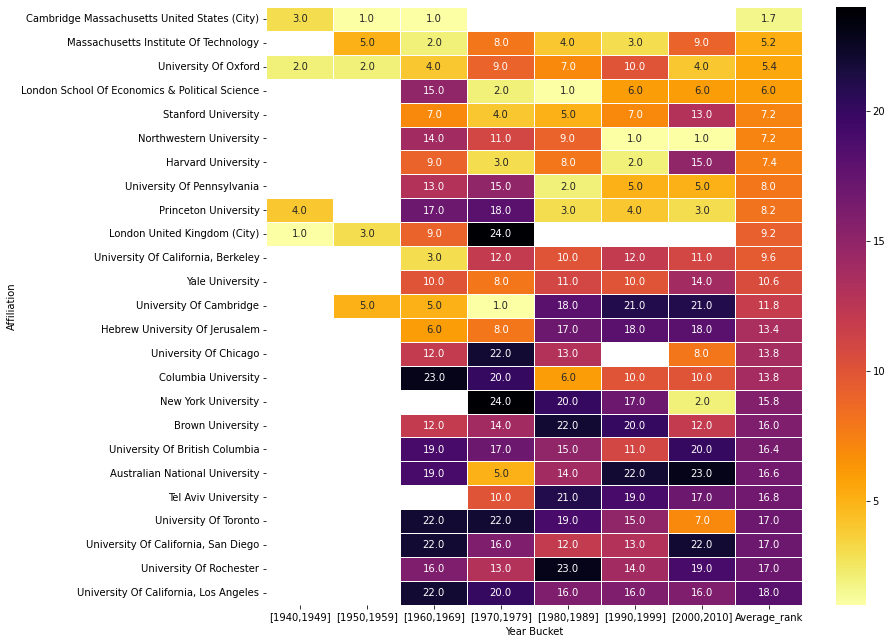

In [35]:
import seaborn as sns
import matplotlib.pyplot as plt


ranked = ranked.replace(0, '')
invert_pivot = ranked.pivot(index='Affiliation', columns='Year Bucket', values='Rank')
invert_pivot['Average_rank'] = invert_pivot.mean(axis=1)

invert_pivot = invert_pivot.sort_values(by='Average_rank', ascending=True)


f, ax = plt.subplots(figsize=(12, 11))
cmap = plt.get_cmap('inferno_r')
sns.heatmap(invert_pivot, annot=True, fmt=".1f", cmap = cmap, linewidths=.5, ax=ax)

Year Bucket                                     [1940,1949]  [1950,1959]  \
Affiliation                                                                
Australian National University                          NaN          NaN   
Brown University                                        NaN          NaN   
Cambridge Massachusetts United States (City)           11.0         37.5   
Columbia University                                     NaN          NaN   
Harvard University                                      NaN          NaN   
Hebrew University Of Jerusalem                          NaN          NaN   
London School Of Economics & Political Science          NaN          NaN   
London United Kingdom (City)                           28.0         18.5   
Massachusetts Institute Of Technology                   NaN          1.0   
New York University                                     NaN          NaN   
Northwestern University                                 NaN          NaN   
Princeton Un

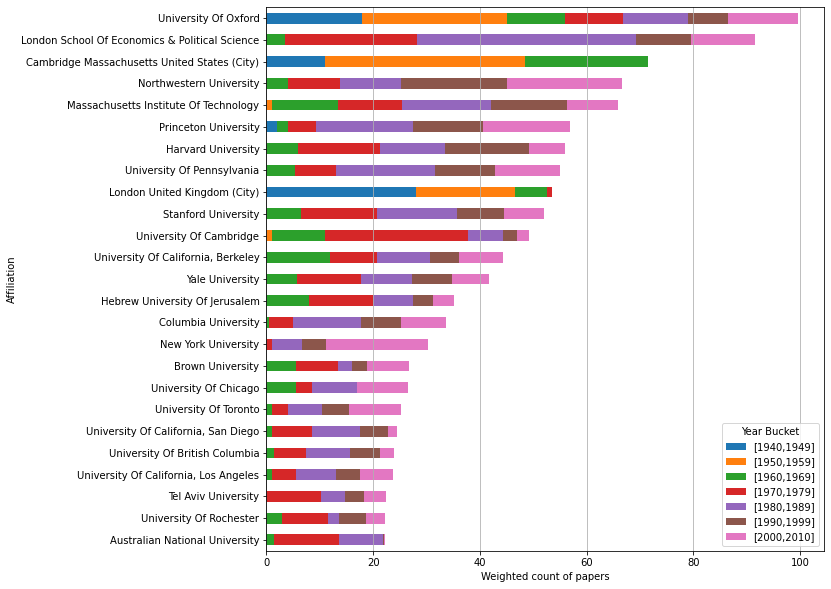

In [ ]:
p = ranked.pivot(index='Affiliation', columns='Year Bucket', values='aff_cum_sum_decade')
print(p)
p['sum_cols'] = p.sum(axis=1)
p = p.sort_values(by='sum_cols', ascending=True)
p = p.drop(['sum_cols'], axis=1)

ax = p.plot.barh(stacked=True, figsize=(10, 10))
#plt.xticks(np.arange(0, 375, step=25))
plt.xlabel('Weighted count of papers')
plt.grid(axis = 'x')
plt.show()
